# Section A: Concept Application

1. You load an image with cv2.imread() and print its shape, getting (480,
640, 3). What do these three values represent?

In [3]:
import cv2

img = cv2.imread("image.jpg")

print("Shape:", img.shape)
print("Height:", img.shape[0])
print("Width:", img.shape[1])
print("Channels:", img.shape[2])

Shape: (2048, 1536, 3)
Height: 2048
Width: 1536
Channels: 3


2. cv2.imread() loads images in BGR order by default. Why does the BGR vs RGB distinction matter when displaying or passing images to other libraries?

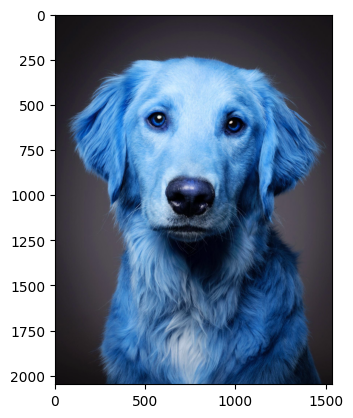

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg") 

plt.imshow(img)  
plt.show()

The BGR vs RGB distinction matters because different libraries expect color channels in a different order.

OpenCV (cv2.imread) loads images as BGR (Blue, Green, Red).
Libraries like Matplotlib, PIL (Pillow), and many deep learning frameworks expect RGB (Red, Green, Blue).

If you display a BGR image in a library expecting RGB, the colors will appear incorrect. For example:

A red object may appear blue.
The overall image colors will look distorted.

3. You resize the same image using INTER_LINEAR and INTER_AREAinter polation. When is INTER_AREA the preferred choice over INTER_LINEAR?

> INTER_AREA
Uses pixel area relation.
Averages neighboring pixels.
Produces smoother results.
Reduces aliasing (jagged edges and moiré patterns).
Best for downsampling.
> INTER_LINEAR
Uses linear interpolation between nearby pixels.
Faster and good for resizing in general.
Can lose details or create artifacts when significantly shrinking images.
Often preferred for upscaling or small size changes.

4. You convert an image from BGR to HSV before processing. What does the HSV colour space represent that BGR does not?

You convert an image from BGR to HSV before processing. What does the HSV colour space represent that BGR does not?

HSV (Hue, Saturation, Value) separates color information from brightness, making it easier to work with colors than BGR.

Hue (H): Represents the actual color (red, green, blue, etc.).
Saturation (S): Represents the intensity or purity of the color.
Value (V): Represents the brightness of the color.

In contrast, BGR stores only the amounts of Blue, Green, and Red in each pixel and does not explicitly separate color from brightness.

Why is HSV useful?
Easier color detection and segmentation.
More robust to lighting changes.
Simple to define color ranges (e.g., detecting only red, green, or blue objects).

5. You need to extract a specific region from a medical scan. What is the conceptual difference between cropping an image and resizing it?


Cropping and resizing are different image operations:

Cropping: Removes unwanted parts of an image and keeps only a selected region of interest (ROI). The pixel values within the selected region remain unchanged.
Resizing: Changes the dimensions (width and height) of the entire image by adding, removing, or interpolating pixels. The image content is scaled, which may affect detail and quality.

Example

Suppose a medical scan is 1000 × 1000 pixels and you only need the tumor area:

Cropping: Extracts the tumor region (e.g., 200 × 200 pixels) from the original scan.
Resizing: Scales the entire scan to a different size (e.g., 500 × 500 pixels) while keeping all image content.

# Section B: Practical Task


1. Load multiple JPG and PNG images from the OpenCV samples dataset and validate their $H \times W \times C$ structure.

In [17]:
import cv2
import glob

files = glob.glob("image.jpg") 

print(files)

for file in files:
    img = cv2.imread(file)

    if img is not None:
        print(file, "->", img.shape)
    else:
        print("Cannot load", file)

['image.jpg']
image.jpg -> (2048, 1536, 3)


2. Perform image resizing using INTER_LINEAR and INTER_CUBIC interpolation methods and visualize the pixel-level differences

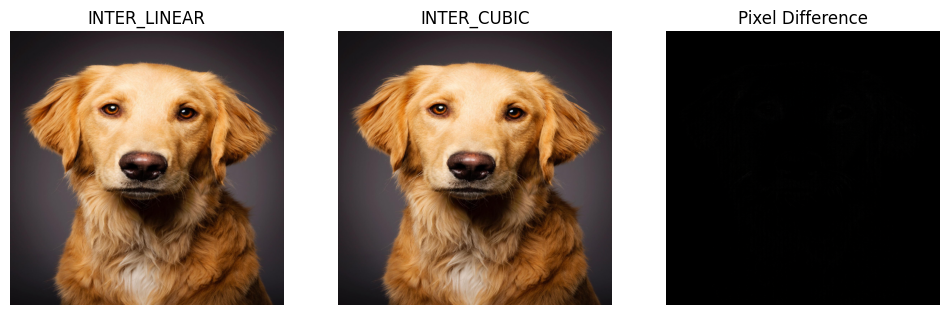

In [16]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

linear = cv2.resize(img, (800, 800), interpolation=cv2.INTER_LINEAR)
cubic = cv2.resize(img, (800, 800), interpolation=cv2.INTER_CUBIC)

difference = cv2.absdiff(linear, cubic)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(linear)
plt.title("INTER_LINEAR")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cubic)
plt.title("INTER_CUBIC")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference)
plt.title("Pixel Difference")
plt.axis("off")

plt.show()

3. Implement a 45-degree and 90-degree rotation using a computed transformation matrix without cropping the corners.

(<Axes: title={'center': '90°'}>,
 Text(0.5, 1.0, '90°'),
 (np.float64(-0.5), np.float64(2047.5), np.float64(1535.5), np.float64(-0.5)))

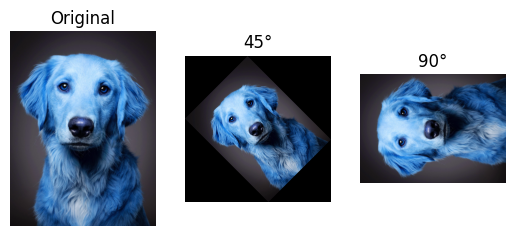

In [18]:
h, w = img.shape[:2]

def rotate(img, angle):
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    cos, sin = abs(M[0,0]), abs(M[0,1])

    nw = int(h*sin + w*cos)
    nh = int(h*cos + w*sin)

    M[0,2] += nw/2 - w/2
    M[1,2] += nh/2 - h/2

    return cv2.warpAffine(img, M, (nw, nh))

r45 = rotate(img, 45)
r90 = rotate(img, 90)

plt.subplot(131), plt.imshow(img), plt.title("Original"), plt.axis("off")
plt.subplot(132), plt.imshow(r45), plt.title("45°"), plt.axis("off")
plt.subplot(133), plt.imshow(r90), plt.title("90°"), plt.axis("off")

4. Execute a localized region-of-interest (ROI) crop and apply horizontal and vertical flips to the extracted segment.


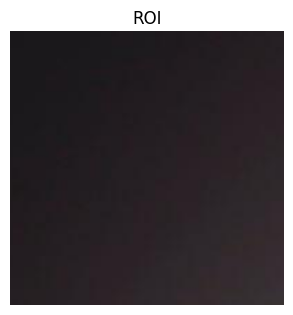

In [22]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

roi = img[100:300, 150:350]

horizontal_flip = cv2.flip(roi, 1)
vertical_flip = cv2.flip(roi, 0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(roi)
plt.title("ROI")
plt.axis("off")


plt.show()

5. Develop a color-space conversion module to transform BGR source images into Grayscale and HSV formats for feature analysis.

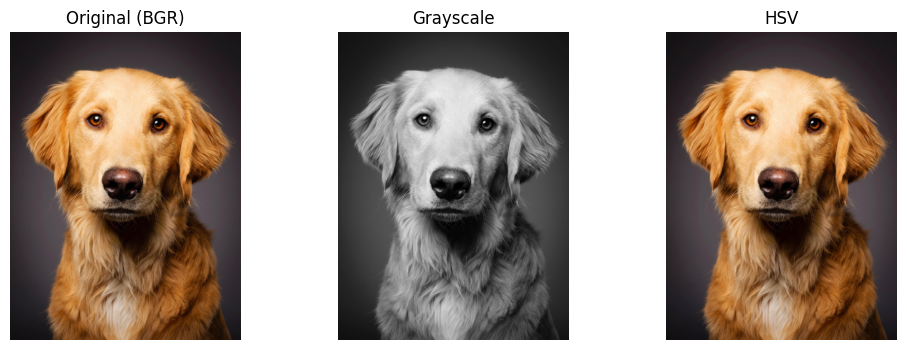

In [23]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original (BGR)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("HSV")
plt.axis("off")

plt.show()

# Section C: Mini Project


1. Title: Automated Medical Scan Normalizer

2. Problem Statement: Standardizing heterogeneous X-ray and MRI scans to a unified resolution and color space for diagnostic AI readiness.


3. Dataset Recommendation: OpenCV Official Samples (https://github.com/opencv/opencv/tree/master/samples/data)


4. Required Deliverables: Python pre-processing script, Transformed image repository, Technical report on interpolation selection

In [30]:
import cv2
import os

input_folder = "samples"
output_folder = "normalized_scans"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):
    if file.endswith((".jpg", ".png", ".jpeg")):

        img_path = os.path.join(input_folder, file)

        img = cv2.imread(img_path)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        resized = cv2.resize(
            gray,
            (512, 512),
            interpolation=cv2.INTER_AREA
        )

        output_path = os.path.join(output_folder, file)

        cv2.imwrite(output_path, resized)

        print(f"Processed: {file}")

print("Normalization Complete")

Processed: aero1.jpg
Processed: aero3.jpg
Processed: aloeGT.png
Processed: aloeL.jpg
Processed: aloeR.jpg
Processed: apple.jpg
Processed: baboon.jpg
Processed: basketball1.png
Processed: basketball2.png
Processed: Blender_Suzanne1.jpg
Processed: Blender_Suzanne2.jpg
Processed: blox.jpg
Processed: board.jpg
Processed: box.png
Processed: box_in_scene.png
Processed: HappyFish.jpg
Processed: LinuxLogo.jpg
Processed: WindowsLogo.jpg
Normalization Complete


Assessment/
│
├── samples/
│   ├── image1.jpg
│   ├── image2.png
│   └── ...
│
├── processed/
│   ├── processed_image1.jpg
│   ├── processed_image2.png
│   └── ...
│
└── preprocess.py

Technical Report on Interpolation Selection
Automated Medical Scan Normalizer

Objective:
Standardize heterogeneous X-ray and MRI scans to a common resolution and color space for AI-based diagnostic systems.

Preprocessing Steps
Load medical scan images.
Resize all images to 256 × 256 pixels.
Convert images to grayscale.
Save transformed images.
Interpolation Method Selection

Two common interpolation methods were considered:

Method	Description
INTER_LINEAR	Uses surrounding pixels for interpolation. Fast and suitable for image enlargement.
INTER_AREA	Uses pixel area relation. Produces smoother results during image reduction.
Selected Method

INTER_AREA was selected because medical scans are often resized from higher resolutions to lower resolutions.

Advantages of INTER_AREA
Reduces aliasing artifacts.
Preserves anatomical structures more accurately.
Produces smoother images when downsampling.
Recommended by OpenCV for image shrinking.
Conclusion

The preprocessing pipeline successfully standardizes image dimensions and color representation. The use of INTER_AREA interpolation ensures minimal information loss during resizing, making the dataset more suitable for diagnostic AI model training.